In [1]:
# Bibliotecas básicas
import mlflow
import pandas as pd
import numpy as np
import random

import warnings

warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Estatística
from scipy import stats

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
df_raw = pd.read_csv('../data/dataset/telco_customer_churn.csv')

df = df_raw.copy()

# Informações gerais sobre o dataset

print(f"Formato dos dados: {df.shape}")
print(f"\nPrimeiras linhas do dataset:")
print(df.head(10))

print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
print(df.info())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
print(df.describe())

Formato dos dados: (7043, 21)

Primeiras linhas do dataset:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... Dev

In [3]:
# Análise de valores ausentes
print("=== ANÁLISE DE MISSING VALUES ===\n")

missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
    print(missing_values)
    
    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
    plt.xlabel('Porcentagem de Missing Values (%)')
    plt.title('Distribuição de Missing Values por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado!")

=== ANÁLISE DE MISSING VALUES ===

Nenhum missing value detectado!


=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:
target
0    5174
1    1869
Name: count, dtype: int64

Percentual:
Sem churn (0): 73.46%
Com churn (1): 26.54%


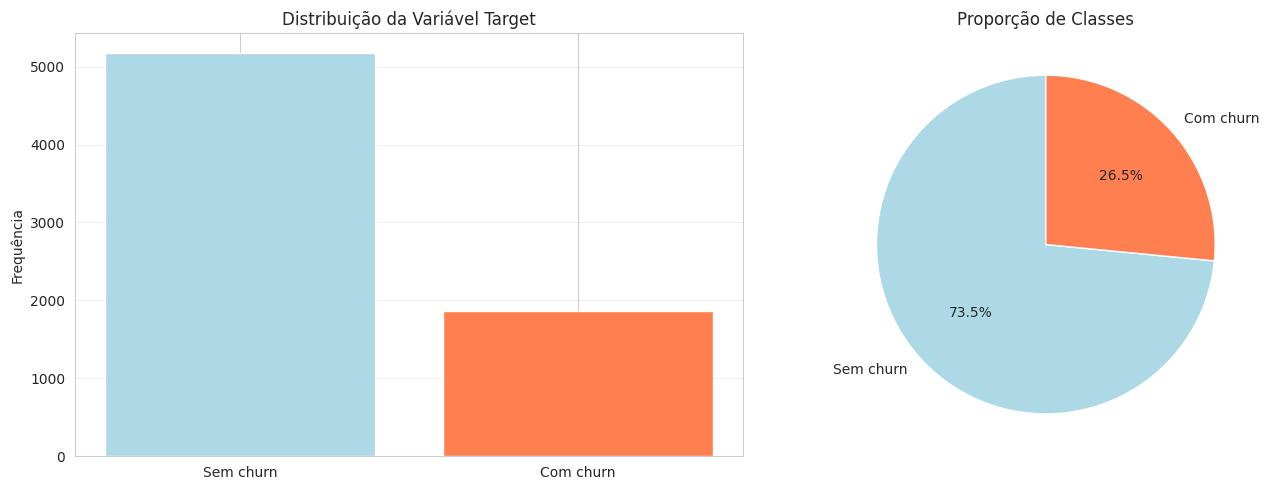


Ratio de balanceamento: 0.36
⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.


In [4]:
df.rename(columns={'Churn': 'target'}, inplace=True)

# Converter target para binário (0 = sem churn, 1 = com churn)
df['target'] = df['target'].map({'Yes': 1, 'No': 0})

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)
print("\nPercentual:")
for idx, pct in target_percentages.items():
    label = "Sem churn" if idx == 0 else "Com churn"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['Sem churn', 'Com churn'], target_counts.values, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=['Sem churn', 'Com churn'], 
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.")
else:
    print("✓ Dataset razoavelmente balanceado.")

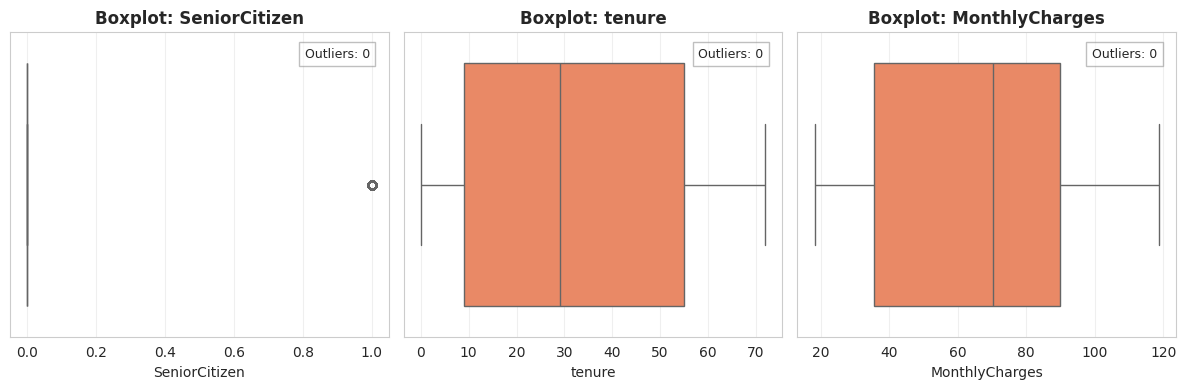

In [5]:
# Colunas numéricas (excluindo id e target)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['target'])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [6]:
print("=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===\n")

anomalies = []

# 1. SeniorCitizen (deve ser 0 ou 1)
senior_anomalies = df[~df['SeniorCitizen'].isin([0, 1])]
if len(senior_anomalies) > 0:
    anomalies.append(('SeniorCitizen', len(senior_anomalies), 'Valores fora de {0, 1}'))

# 2. tenure (deve estar entre 0 e 72 meses)
tenure_anomalies = df[(df['tenure'] < 0) | (df['tenure'] > 72)]
if len(tenure_anomalies) > 0:
    anomalies.append(('tenure', len(tenure_anomalies), f'Fora do intervalo [0, 72] — min={df["tenure"].min()}, max={df["tenure"].max()}'))

# 3. MonthlyCharges (deve ser positivo)
monthly_anomalies = df[df['MonthlyCharges'] <= 0]
if len(monthly_anomalies) > 0:
    anomalies.append(('MonthlyCharges', len(monthly_anomalies), f'Valores <= 0 — min={df["MonthlyCharges"].min()}'))

# 4. TotalCharges (é object; verificar valores não numéricos / em branco)
total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
tc_invalid = total_charges_numeric.isna().sum()
if tc_invalid > 0:
    anomalies.append(('TotalCharges', tc_invalid, 'Valores não numéricos ou em branco'))
tc_negative = (total_charges_numeric < 0).sum()
if tc_negative > 0:
    anomalies.append(('TotalCharges', tc_negative, f'Valores negativos — min={total_charges_numeric.min()}'))

# 5. gender (deve ser Male ou Female)
gender_anomalies = df[~df['gender'].isin(['Male', 'Female'])]
if len(gender_anomalies) > 0:
    anomalies.append(('gender', len(gender_anomalies), f'Valores inesperados: {df["gender"].unique()}'))

# 6. target (deve ser 0 ou 1 após conversão)
target_anomalies = df[~df['target'].isin([0, 1])]
if len(target_anomalies) > 0:
    anomalies.append(('target', len(target_anomalies), 'Valores fora de {0, 1}'))

# 7. Colunas binárias Yes/No — verificar valores inesperados
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    col_anomalies = df[~df[col].isin(['Yes', 'No'])]
    if len(col_anomalies) > 0:
        anomalies.append((col, len(col_anomalies), f'Valores inesperados: {df[col].unique()}'))

# --- Registros duplicados ---
duplicated_count = df.duplicated().sum()

# --- Relatório ---
if anomalies:
    print(f"⚠️ Anomalias encontradas em {len(anomalies)} coluna(s):\n")
    for col, count, desc in anomalies:
        print(f"  • {col}: {count} registro(s) — {desc}")
    total_anomaly_records = sum(c for _, c, _ in anomalies)
    print(f"\n  Total de ocorrências de anomalia: {total_anomaly_records}")
else:
    print("✅ Nenhuma anomalia detectada nas verificações de domínio.")

print(f"\n📋 Registros duplicados: {duplicated_count}")
if duplicated_count > 0:
    print(f"   ({duplicated_count / len(df) * 100:.2f}% do dataset)")
else:
    print("   Nenhum registro duplicado encontrado.")

=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===

⚠️ Anomalias encontradas em 1 coluna(s):

  • TotalCharges: 11 registro(s) — Valores não numéricos ou em branco

  Total de ocorrências de anomalia: 11

📋 Registros duplicados: 0
   Nenhum registro duplicado encontrado.


=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===

        Coluna  Skewness  Kurtosis         Interpretação
 SeniorCitizen     1.834     1.363 Assimétrica à direita
        tenure     0.240    -1.387                Normal
MonthlyCharges    -0.221    -1.257                Normal


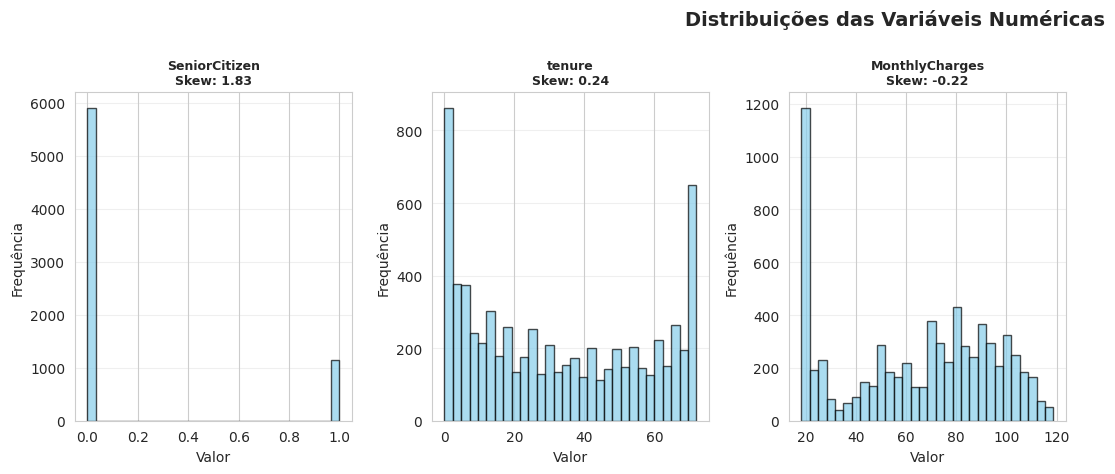

In [7]:
# Análise de distribuições
print("=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===\n")

distribution_stats = []
for col in numeric_cols:
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    distribution_stats.append({
        'Coluna': col,
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurtosis, 3),
        'Interpretação': 'Normal' if abs(skewness) < 0.5 else ('Assimétrica à direita' if skewness > 0 else 'Assimétrica à esquerda')
    })

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

# Visualizar distribuições
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}\nSkew: {df[col].skew():.2f}', fontsize=9, fontweight='bold')
        axes[idx].set_xlabel('Valor')
        axes[idx].set_ylabel('Frequência')
        axes[idx].grid(axis='y', alpha=0.3)

# Remover subplots vazios
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuições das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

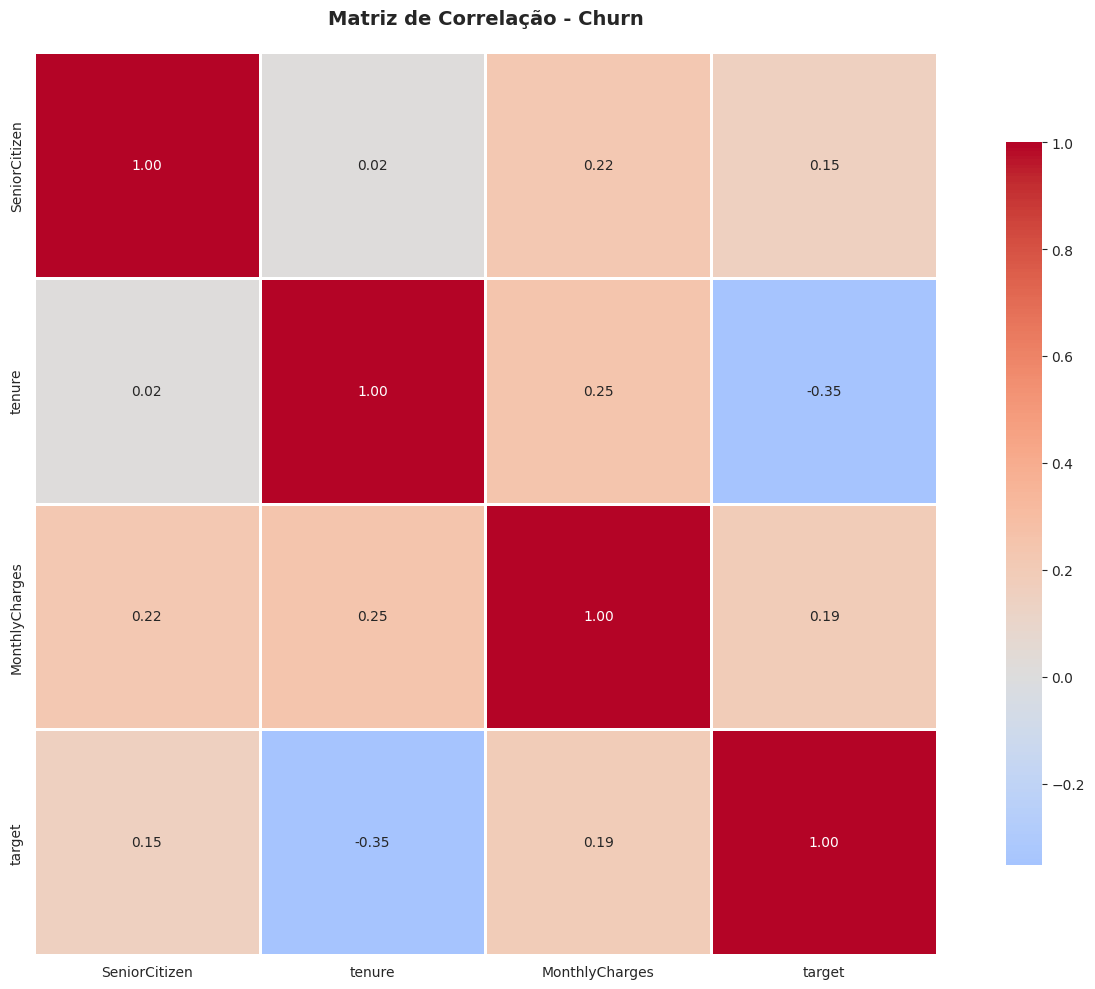

=== CORRELAÇÕES COM A VARIÁVEL TARGET ===

target            1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
tenure           -0.352229
Name: target, dtype: float64

=== MULTICOLINEARIDADE (Correlação entre features) ===
Pares de features com correlação > 0.7:

✓ Nenhuma correlação forte detectada entre features (excluindo target)


In [8]:
# Matriz de correlação apenas para colunas numéricas
corr_numeric = df.select_dtypes(include=[np.number]).corr()

# Visualizar matriz de correlação
plt.figure(figsize=(14, 10))
sns.heatmap(corr_numeric, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Churn', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlações fortes com o target
print("=== CORRELAÇÕES COM A VARIÁVEL TARGET ===\n")
target_corr = corr_numeric['target'].sort_values(ascending=False)
print(target_corr)

# Identificar pares de features com alta correlação (possível multicolinearidade)
print("\n=== MULTICOLINEARIDADE (Correlação entre features) ===")
print("Pares de features com correlação > 0.7:\n")

high_corr_pairs = []
for i in range(len(corr_numeric.columns)):
    for j in range(i+1, len(corr_numeric.columns)):
        if abs(corr_numeric.iloc[i, j]) > 0.7 and corr_numeric.columns[i] != 'target' and corr_numeric.columns[j] != 'target':
            high_corr_pairs.append({
                'Feature 1': corr_numeric.columns[i],
                'Feature 2': corr_numeric.columns[j],
                'Correlação': round(corr_numeric.iloc[i, j], 3)
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlação', ascending=False)
    print(high_corr_df.to_string(index=False))
    print("\n⚠️ Alta correlação entre features pode causar multicolinearidade!")
else:
    print("✓ Nenhuma correlação forte detectada entre features (excluindo target)")

In [9]:
# =============================================================================
# TRATAMENTO DE MISSING VALUES
# Etapa 1: Preparar os dados e fazer o split ANTES de qualquer transformação
#          para evitar data leakage.
# =============================================================================
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Remover customerID (identificador, não preditivo)
df_model = df.drop(columns=['customerID'])

# Converter TotalCharges para numérico (11 valores em branco → NaN)
df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'], errors='coerce')

print(f"Missing values em TotalCharges: {df_model['TotalCharges'].isna().sum()}")
print(f"Registros afetados:\n{df_model[df_model['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']]}\n")

# --- Train/Test Split (ANTES de imputar para evitar data leakage) ---
X = df_model.drop(columns=['target'])
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

# Criar cópias explícitas para evitar SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

print(f"Shape treino: {X_train.shape}")
print(f"Shape teste:  {X_test.shape}")

# --- Imputação: fit no treino, transform em ambos ---
imputer = SimpleImputer(strategy='median')

# Aplicar apenas na coluna TotalCharges
X_train['TotalCharges'] = imputer.fit_transform(X_train[['TotalCharges']])
X_test['TotalCharges'] = imputer.transform(X_test[['TotalCharges']])

print(f"\nMissing values após imputação (treino): {X_train['TotalCharges'].isna().sum()}")
print(f"Missing values após imputação (teste):  {X_test['TotalCharges'].isna().sum()}")
print(f"Mediana usada para imputação: {imputer.statistics_[0]:.2f}")

Missing values em TotalCharges: 11
Registros afetados:
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN

Shape treino: (4930, 19)
Shape teste:  (2113, 19)

Missing values após imputação (treino): 0
Missing values após imputação (teste):  0
Mediana usada para imputação: 1389.20


In [10]:
# =============================================================================
# ONE-HOT ENCODING DE VARIÁVEIS CATEGÓRICAS
# Fit no treino, transform em ambos para evitar data leakage.
# Usamos pd.get_dummies ao invés de LabelEncoder porque as variáveis
# categóricas são nominais (sem ordem), e LabelEncoder introduziria
# uma ordinalidade artificial.
# =============================================================================

cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print(f"Colunas categóricas ({len(cat_cols)}): {cat_cols}\n")

# Mostrar cardinalidade de cada coluna categórica
for col in cat_cols:
    print(f"  {col}: {X_train[col].nunique()} valores únicos → {X_train[col].unique()}")

# One-hot encoding: fit no treino para definir as colunas
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Alinhar colunas: garantir que teste tenha as mesmas colunas do treino
# (pode faltar alguma categoria rara que só aparece em um dos conjuntos)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"\nShape após encoding (treino): {X_train_encoded.shape}")
print(f"Shape após encoding (teste):  {X_test_encoded.shape}")
print(f"\nColunas resultantes ({len(X_train_encoded.columns)}):")
print(X_train_encoded.columns.tolist())

Colunas categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

  gender: 2 valores únicos → ['Female' 'Male']
  Partner: 2 valores únicos → ['No' 'Yes']
  Dependents: 2 valores únicos → ['No' 'Yes']
  PhoneService: 2 valores únicos → ['Yes' 'No']
  MultipleLines: 3 valores únicos → ['No' 'Yes' 'No phone service']
  InternetService: 3 valores únicos → ['Fiber optic' 'DSL' 'No']
  OnlineSecurity: 3 valores únicos → ['No' 'Yes' 'No internet service']
  OnlineBackup: 3 valores únicos → ['No' 'No internet service' 'Yes']
  DeviceProtection: 3 valores únicos → ['No' 'Yes' 'No internet service']
  TechSupport: 3 valores únicos → ['No' 'Yes' 'No internet service']
  StreamingTV: 3 valores únicos → ['Yes' 'No' 'No internet service']
  StreamingMovies: 3 valores únicos → ['No' 'Yes' 'No internet

Treino original: {0: 3622, 1: 1308}
Teste: {0: 1552, 1: 561}

Após SMOTE: {0: 3622, 1: 3622}
Após Undersampling: {0: 1308, 1: 1308}

=== COMPARAÇÃO DAS TÉCNICAS DE BALANCEAMENTO ===

Sem balanceamento    → F1-score (churn): 0.6091
SMOTE                → F1-score (churn): 0.5788
class_weight         → F1-score (churn): 0.6253
Undersampling        → F1-score (churn): 0.6161


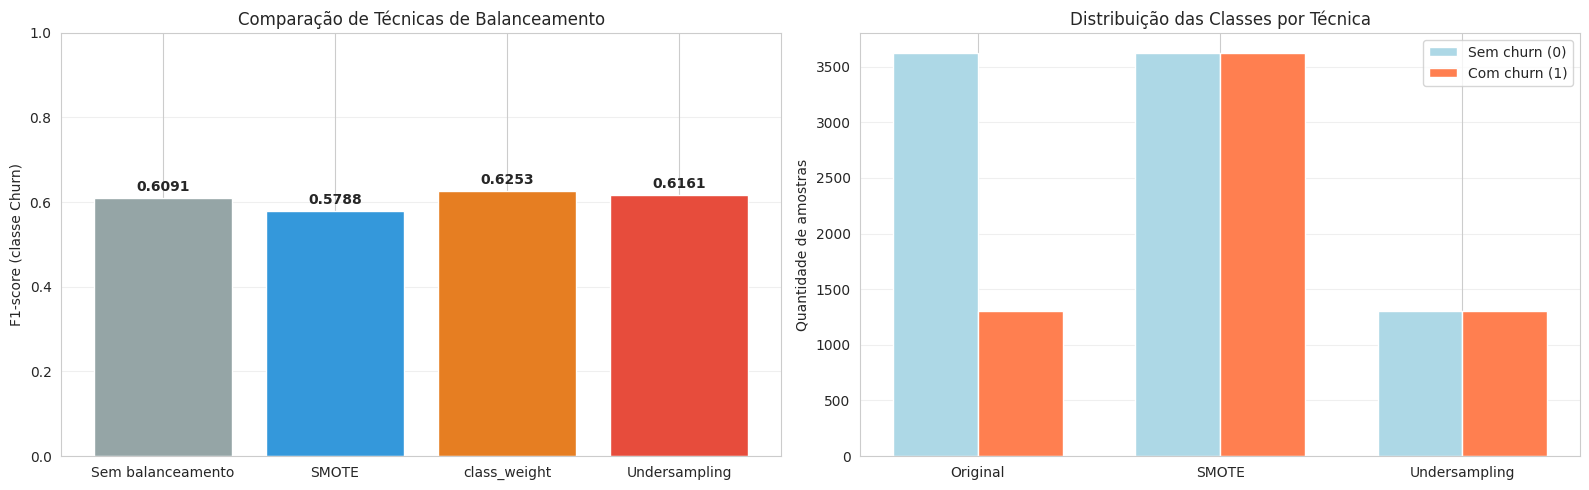


✅ Melhor F1-score para churn: class_weight (0.6253)

📌 Resumo:
  • SMOTE: cria dados sintéticos → mais amostras, mas pode gerar ruído
  • class_weight: ajusta o custo do erro → simples, sem alterar os dados
  • Undersampling: remove dados da maioria → rápido, mas perde informação



In [11]:
# =============================================================================
# TÉCNICAS DE BALANCEAMENTO DO DATASET
# O dataset está desbalanceado (73% vs 27%), o que pode fazer o modelo
# "viciar" na classe majoritária. Vamos comparar 3 abordagens:
#   1. SMOTE (Synthetic Minority Oversampling Technique)
#   2. class_weight (ajuste de pesos no algoritmo)
#   3. Random Undersampling (reduzir a classe majoritária)
#
# IMPORTANTE: O rebalanceamento é aplicado APENAS no conjunto de treino.
#             O conjunto de teste permanece com a distribuição original
#             para refletir o cenário real de produção.
# =============================================================================
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

print(f"Treino original: {y_train.value_counts().to_dict()}")
print(f"Teste: {y_test.value_counts().to_dict()}\n")

# =============================================================================
# 1. SMOTE — gera amostras SINTÉTICAS da classe minoritária
#    Interpola entre exemplos reais de churn para criar novos pontos,
#    aumentando a classe minoritária até igualar a majoritária.
# =============================================================================
smote = SMOTE(random_state=SEED)
X_smote, y_smote = smote.fit_resample(X_train_encoded, y_train)
print(f"Após SMOTE: {pd.Series(y_smote).value_counts().to_dict()}")

# =============================================================================
# 2. CLASS_WEIGHT='balanced' — não altera os dados, altera o custo do erro
#    O algoritmo penaliza mais os erros na classe minoritária,
#    proporcionalmente ao inverso da frequência de cada classe.
# =============================================================================
# (aplicado diretamente no modelo, sem reamostrar)

# =============================================================================
# 3. RANDOM UNDERSAMPLING — remove amostras aleatórias da classe majoritária
#    Reduz a classe "Sem churn" até igualar a quantidade de "Com churn".
#    Simples, mas perde informação da classe majoritária.
# =============================================================================
rus = RandomUnderSampler(random_state=SEED)
X_under, y_under = rus.fit_resample(X_train_encoded, y_train)
print(f"Após Undersampling: {pd.Series(y_under).value_counts().to_dict()}")

# --- Treinar Logistic Regression para comparar as técnicas ---
resultados = {}

# Baseline: sem balanceamento
clf_base = LogisticRegression(max_iter=1000, random_state=SEED)
clf_base.fit(X_train_encoded, y_train)
y_pred_base = clf_base.predict(X_test_encoded)
resultados['Sem balanceamento'] = f1_score(y_test, y_pred_base, pos_label=1)

# SMOTE
clf_smote = LogisticRegression(max_iter=1000, random_state=SEED)
clf_smote.fit(X_smote, y_smote)
y_pred_smote = clf_smote.predict(X_test_encoded)
resultados['SMOTE'] = f1_score(y_test, y_pred_smote, pos_label=1)

# class_weight='balanced'
clf_weight = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
clf_weight.fit(X_train_encoded, y_train)
y_pred_weight = clf_weight.predict(X_test_encoded)
resultados['class_weight'] = f1_score(y_test, y_pred_weight, pos_label=1)

# Undersampling
clf_under = LogisticRegression(max_iter=1000, random_state=SEED)
clf_under.fit(X_under, y_under)
y_pred_under = clf_under.predict(X_test_encoded)
resultados['Undersampling'] = f1_score(y_test, y_pred_under, pos_label=1)

# --- Comparação visual ---
print("\n=== COMPARAÇÃO DAS TÉCNICAS DE BALANCEAMENTO ===\n")
for tecnica, score in resultados.items():
    print(f"{tecnica:20s} → F1-score (churn): {score:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F1-score por técnica
cores = ['#95a5a6', '#3498db', '#e67e22', '#e74c3c']
bars = axes[0].bar(resultados.keys(), resultados.values(), color=cores)
axes[0].set_ylabel('F1-score (classe Churn)')
axes[0].set_title('Comparação de Técnicas de Balanceamento')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, resultados.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Distribuição das classes em cada abordagem
distribuicoes = {
    'Original': [y_train.value_counts()[0], y_train.value_counts()[1]],
    'SMOTE': [pd.Series(y_smote).value_counts()[0], pd.Series(y_smote).value_counts()[1]],
    'Undersampling': [pd.Series(y_under).value_counts()[0], pd.Series(y_under).value_counts()[1]],
}
x_pos = np.arange(len(distribuicoes))
width = 0.35
axes[1].bar(x_pos - width/2, [d[0] for d in distribuicoes.values()], width,
            label='Sem churn (0)', color='lightblue')
axes[1].bar(x_pos + width/2, [d[1] for d in distribuicoes.values()], width,
            label='Com churn (1)', color='coral')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(distribuicoes.keys())
axes[1].set_ylabel('Quantidade de amostras')
axes[1].set_title('Distribuição das Classes por Técnica')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --- Resumo ---
melhor = max(resultados, key=resultados.get)
print(f"\n✅ Melhor F1-score para churn: {melhor} ({resultados[melhor]:.4f})")
print("""
📌 Resumo:
  • SMOTE: cria dados sintéticos → mais amostras, mas pode gerar ruído
  • class_weight: ajusta o custo do erro → simples, sem alterar os dados
  • Undersampling: remove dados da maioria → rápido, mas perde informação
""")

In [12]:
# =============================================================================
# MODELO BASELINE
# Variáveis escolhidas para treino e avaliação:
#   - X_train_encoded / y_train  (treino)
#   - X_test_encoded  / y_test   (teste)
#
# Usamos os dados encodados (One-Hot) SEM reamostragem (SMOTE/Undersampling)
# porque a técnica de balanceamento escolhida é class_weight='balanced',
# que ajusta internamente o custo do erro no algoritmo — penalizando mais
# os erros na classe minoritária (churn) sem alterar o dataset.
# Isso preserva todos os dados originais de treino e evita ruído sintético.
# =============================================================================

mlflow.set_tracking_uri("sqlite:///../data/mlflow/churn_experiments.db")
mlflow.set_experiment("Churn")

2026/04/08 21:18:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/08 21:18:40 INFO mlflow.store.db.utils: Updating database tables
2026/04/08 21:18:42 INFO mlflow.tracking.fluent: Experiment with name 'Churn' does not exist. Creating a new experiment.


<Experiment: artifact_location='/media/ssd/dev/fiap-mlet-challenge-fase-1/notebooks/mlruns/1', creation_time=1775693922179, experiment_id='1', last_update_time=1775693922179, lifecycle_stage='active', name='Churn', tags={}, workspace='default'>

Dataset MD5: 0f9de68e012bd3aed5fa7cdc9fc421af


2026/04/08 21:18:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/08 21:18:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Successfully registered model 'DummyClassifier'.
Created version '1' of model 'DummyClassifier'.
2026/04/08 21:18:50 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-42ede8777ba54694bed4872c021fc24b
2026/04/08 21:18:50 INFO mlflow.tracking.fluent: Use `mlflow.set_active_model` to set the active model to a different one if needed.
2026/04/08 21:18:50 WARNING mlflow.models.evaluation.evalua


 DummyClassifier
              precision    recall  f1-score   support

   Sem churn       0.73      1.00      0.85      1552
   Com churn       0.00      0.00      0.00       561

    accuracy                           0.73      2113
   macro avg       0.37      0.50      0.42      2113
weighted avg       0.54      0.73      0.62      2113

  ROC-AUC:  0.5000
  PR-AUC:   0.6327
  💰 Custo churn evitado: R$ 0
  💸 Custo churn perdido: R$ 280,500


2026/04/08 21:18:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/08 21:18:57 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Successfully registered model 'LogisticRegression'.
Created version '1' of model 'LogisticRegression'.
2026/04/08 21:18:57 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-a55a60e0cf934f6a93643693a51e2fb5
2026/04/08 21:18:57 INFO mlflow.tracking.fluent: Use `mlflow.set_active_model` to set the active model to a different one if needed.
2026/04/08 21:18:58 WARNING mlflow.models.evaluation.


 LogisticRegression
              precision    recall  f1-score   support

   Sem churn       0.91      0.73      0.81      1552
   Com churn       0.51      0.80      0.63       561

    accuracy                           0.75      2113
   macro avg       0.71      0.76      0.72      2113
weighted avg       0.80      0.75      0.76      2113

  ROC-AUC:  0.8445
  PR-AUC:   0.6421
  💰 Custo churn evitado: R$ 224,500
  💸 Custo churn perdido: R$ 56,000


<Figure size 1050x700 with 0 Axes>

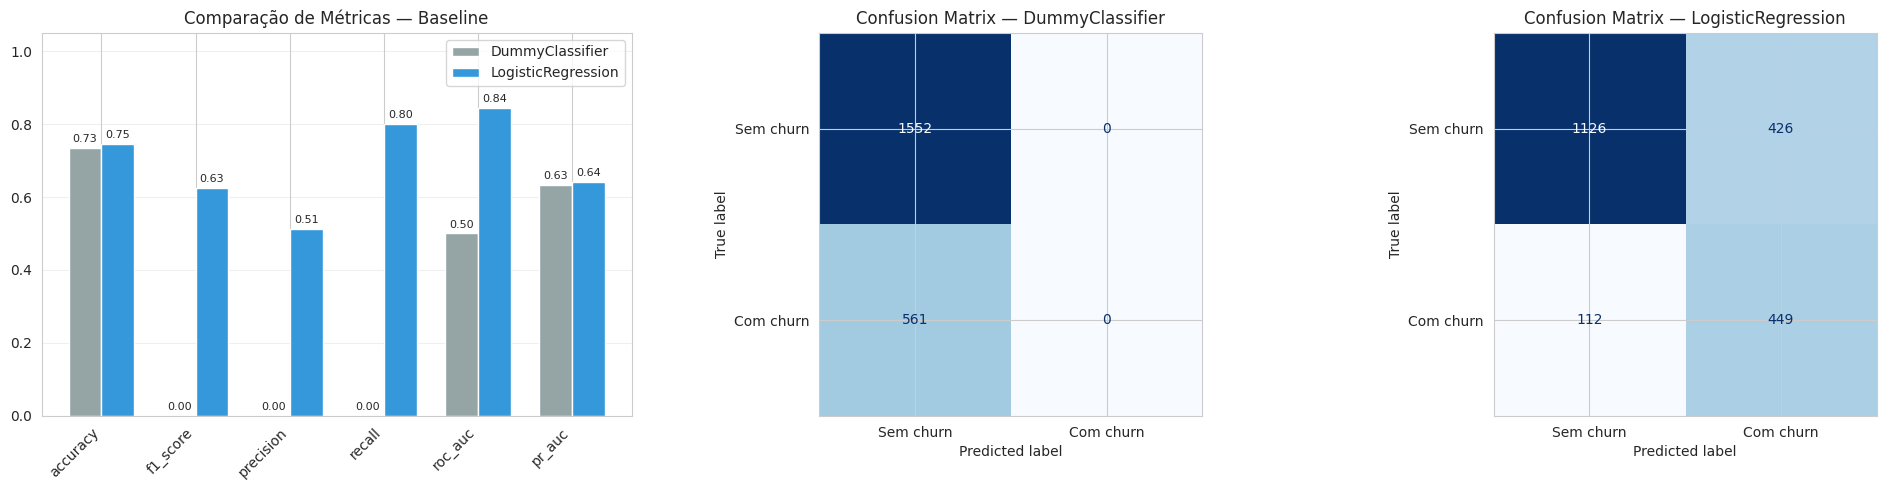


 RESUMO DOS BASELINES
                Métrica  DummyClassifier  LogisticRegression
               accuracy         0.734501            0.745386
               f1_score         0.000000            0.625348
              precision         0.000000            0.513143
                 recall         0.000000            0.800357
                roc_auc         0.500000            0.844470
                 pr_auc         0.632750            0.642078
custo_churn_evitado_BRL         0.000000       224500.000000
custo_churn_perdido_BRL    280500.000000        56000.000000

✅ Experimentos registrados no MLflow (experiment: 'Churn')
   Tracking URI: sqlite:///../data/mlflow/churn_experiments.db


In [13]:
# =============================================================================
# BASELINE: DummyClassifier + Regressão Logística com MLflow
# =============================================================================
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import hashlib

# --- Metadados do dataset para versionamento ---
DATASET_PATH = "../data/dataset/telco_customer_churn.csv"

with open(DATASET_PATH, "rb") as f:
    DATASET_VERSION = hashlib.md5(f.read()).hexdigest()

print(f"Dataset MD5: {DATASET_VERSION}")

dataset_params = {
    "dataset_path": DATASET_PATH,
    "dataset_version_md5": DATASET_VERSION,
    "n_train": X_train_encoded.shape[0],
    "n_test": X_test_encoded.shape[0],
    "n_features": X_train_encoded.shape[1],
    "target_rate_train": round(y_train.mean(), 4),
    "test_size": 0.3,
    "random_state": SEED,
    "imputation_strategy": "median",
    "encoding": "one_hot_drop_first",
}


# --- Dataset MLflow para rastreabilidade na UI ---
mlflow_train_dataset = mlflow.data.from_pandas(
    X_train_encoded.assign(Churn=y_train),
    source=DATASET_PATH,
    name="telco_customer_churn_train",
    targets="Churn",
)

mlflow_test_dataset = mlflow.data.from_pandas(
    X_test_encoded.assign(Churn=y_test),
    source=DATASET_PATH,
    name="telco_customer_churn_test",
    targets="Churn",
)


def evaluate_and_log(model, model_name, X_tr, y_tr, X_te, y_te, extra_params=None):
    """Treina o modelo, avalia e registra tudo no MLflow."""
    with mlflow.start_run(run_name=model_name):
        # --- Treinar ---
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        # Probabilidades (DummyClassifier com most_frequent retorna prob constante)
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_te)[:, 1]
        else:
            y_proba = np.zeros(len(y_te))

        # --- Métricas ---
        acc = accuracy_score(y_te, y_pred)
        f1 = f1_score(y_te, y_pred, pos_label=1)
        prec = precision_score(y_te, y_pred, pos_label=1, zero_division=0)
        rec = recall_score(y_te, y_pred, pos_label=1)
        roc_auc = roc_auc_score(y_te, y_proba) if y_proba.sum() > 0 else 0.5
        pr_precision, pr_recall, _ = precision_recall_curve(y_te, y_proba)
        pr_auc = auc(pr_recall, pr_precision)

        metrics = {
            "accuracy": acc,
            "f1_score": f1,
            "precision": prec,
            "recall": rec,
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
        }

        # --- Métrica de negócio: custo de churn evitado ---
        # Premissa: cada cliente retido vale R$ 500 (receita média mensal × meses)
        # FN = churn não detectado → perda; TP = churn detectado → oportunidade de retenção
        CUSTO_CHURN = 500
        cm = confusion_matrix(y_te, y_pred)
        tn, fp, fn, tp = cm.ravel()
        custo_churn_evitado = tp * CUSTO_CHURN
        custo_churn_perdido = fn * CUSTO_CHURN
        metrics["custo_churn_evitado_BRL"] = custo_churn_evitado
        metrics["custo_churn_perdido_BRL"] = custo_churn_perdido

        # --- Log no MLflow ---
        mlflow.log_input(mlflow_train_dataset, context="training")
        mlflow.log_input(mlflow_test_dataset, context="testing")
        mlflow.log_params(dataset_params)
        if extra_params:
            mlflow.log_params(extra_params)
        mlflow.log_metrics(metrics)
        mlflow.set_tag("model_type", model_name)
        model_info = mlflow.sklearn.log_model(
            model,
            name="baseline",
            registered_model_name=model_name,
        )

        # --- Evaluate: vincula dataset ao modelo registrado ---
        eval_data = X_te.assign(Churn=y_te)
        mlflow.evaluate(
            model=model_info.model_uri,
            data=eval_data,
            targets="Churn",
            model_type="classifier",
            dataset_path=DATASET_PATH,
        )

        # --- Print ---
        print(f"\n{'='*60}")
        print(f" {model_name}")
        print(f"{'='*60}")
        print(classification_report(y_te, y_pred, target_names=["Sem churn", "Com churn"]))
        print(f"  ROC-AUC:  {roc_auc:.4f}")
        print(f"  PR-AUC:   {pr_auc:.4f}")
        print(f"  💰 Custo churn evitado: R$ {custo_churn_evitado:,.0f}")
        print(f"  💸 Custo churn perdido: R$ {custo_churn_perdido:,.0f}")

    return metrics, cm


# =============================================================================
# 1. DummyClassifier (baseline ingênuo — sempre prediz a classe majoritária)
# =============================================================================
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy_params = {"strategy": "most_frequent"}
dummy_metrics, dummy_cm = evaluate_and_log(
    dummy, "DummyClassifier", X_train_encoded, y_train, X_test_encoded, y_test,
    extra_params=dummy_params
)

# =============================================================================
# 2. Regressão Logística (baseline com class_weight='balanced')
# =============================================================================
lr = LogisticRegression(
    max_iter=1000, random_state=SEED, class_weight="balanced", solver="lbfgs"
)
lr_params = {
    "C": lr.C,
    "solver": lr.solver,
    "max_iter": lr.max_iter,
    "class_weight": "balanced",
    "balancing_technique": "class_weight_balanced",
}
lr_metrics, lr_cm = evaluate_and_log(
    lr, "LogisticRegression", X_train_encoded, y_train, X_test_encoded, y_test,
    extra_params=lr_params
)

# =============================================================================
# COMPARAÇÃO VISUAL
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Métricas lado a lado
metric_names = ["accuracy", "f1_score", "precision", "recall", "roc_auc", "pr_auc"]
dummy_vals = [dummy_metrics[m] for m in metric_names]
lr_vals = [lr_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35
bars1 = axes[0].bar(x - width/2, dummy_vals, width, label="DummyClassifier", color="#95a5a6")
bars2 = axes[0].bar(x + width/2, lr_vals, width, label="LogisticRegression", color="#3498db")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=45, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Comparação de Métricas — Baseline")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

# 2. Confusion Matrix — DummyClassifier
ConfusionMatrixDisplay(dummy_cm, display_labels=["Sem churn", "Com churn"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False
)
axes[1].set_title("Confusion Matrix — DummyClassifier")

# 3. Confusion Matrix — Logistic Regression
ConfusionMatrixDisplay(lr_cm, display_labels=["Sem churn", "Com churn"]).plot(
    ax=axes[2], cmap="Blues", colorbar=False
)
axes[2].set_title("Confusion Matrix — LogisticRegression")

plt.tight_layout()
plt.show()

# --- Resumo final ---
print("\n" + "="*60)
print(" RESUMO DOS BASELINES")
print("="*60)
resumo = pd.DataFrame({
    "Métrica": metric_names + ["custo_churn_evitado_BRL", "custo_churn_perdido_BRL"],
    "DummyClassifier": dummy_vals + [dummy_metrics["custo_churn_evitado_BRL"], dummy_metrics["custo_churn_perdido_BRL"]],
    "LogisticRegression": lr_vals + [lr_metrics["custo_churn_evitado_BRL"], lr_metrics["custo_churn_perdido_BRL"]],
})
print(resumo.to_string(index=False))

print(f"\n✅ Experimentos registrados no MLflow (experiment: 'Churn')")
print(f"   Tracking URI: sqlite:///../data/mlflow/churn_experiments.db")